In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define path to the extracted 2nd_test data directory
DATA_DIR = os.path.join("data", "2nd_test", "2nd_test")

# Get list of all timestamped files
files = sorted(os.listdir(DATA_DIR))
files = [f for f in files if os.path.isfile(os.path.join(DATA_DIR, f)) and not f.endswith('.rar')]

print(f"Total snapshot files found: {len(files)}")
print(f"First recorded snapshot: {files[0]}")
print(f"Last recorded snapshot:  {files[-1]}")

Total snapshot files found: 984
First recorded snapshot: 2004.02.12.10.32.39
Last recorded snapshot:  2004.02.19.06.22.39


In [3]:
# Read the first sample file (Healthy state)
sample_path = os.path.join(DATA_DIR, files[0])
sample_df = pd.read_csv(sample_path, sep='\t', header=None)
sample_df.columns = ['Bearing_1', 'Bearing_2', 'Bearing_3', 'Bearing_4']

print("--- Data Shape (Rows, Columns) ---")
print(sample_df.shape)
print("\n--- First 5 rows ---")
display(sample_df.head())
print("\n--- Summary Statistics ---")
display(sample_df.describe())

--- Data Shape (Rows, Columns) ---
(20480, 4)

--- First 5 rows ---


,Bearing_1,Bearing_2,Bearing_3,Bearing_4
0,-0.049,-0.071,-0.132,-0.010
1,-0.042,-0.073,-0.007,-0.105
2,0.015,0.000,0.007,0.000
3,-0.051,0.020,-0.002,0.100
4,-0.107,0.010,0.127,0.054



--- Summary Statistics ---


,Bearing_1,Bearing_2,Bearing_3,Bearing_4
count,20480.000000,20480.000000,20480.000000,20480.000000
mean,-0.010196,-0.012695,-0.014541,-0.010026
std,0.073477,0.090056,0.108436,0.053168
min,-0.386000,-0.513000,-0.911000,-0.264000
25%,-0.059000,-0.073000,-0.081000,-0.046000
50%,-0.010000,-0.015000,-0.015000,-0.010000
75%,0.037000,0.046000,0.051000,0.027000
max,0.454000,0.464000,1.023000,0.193000


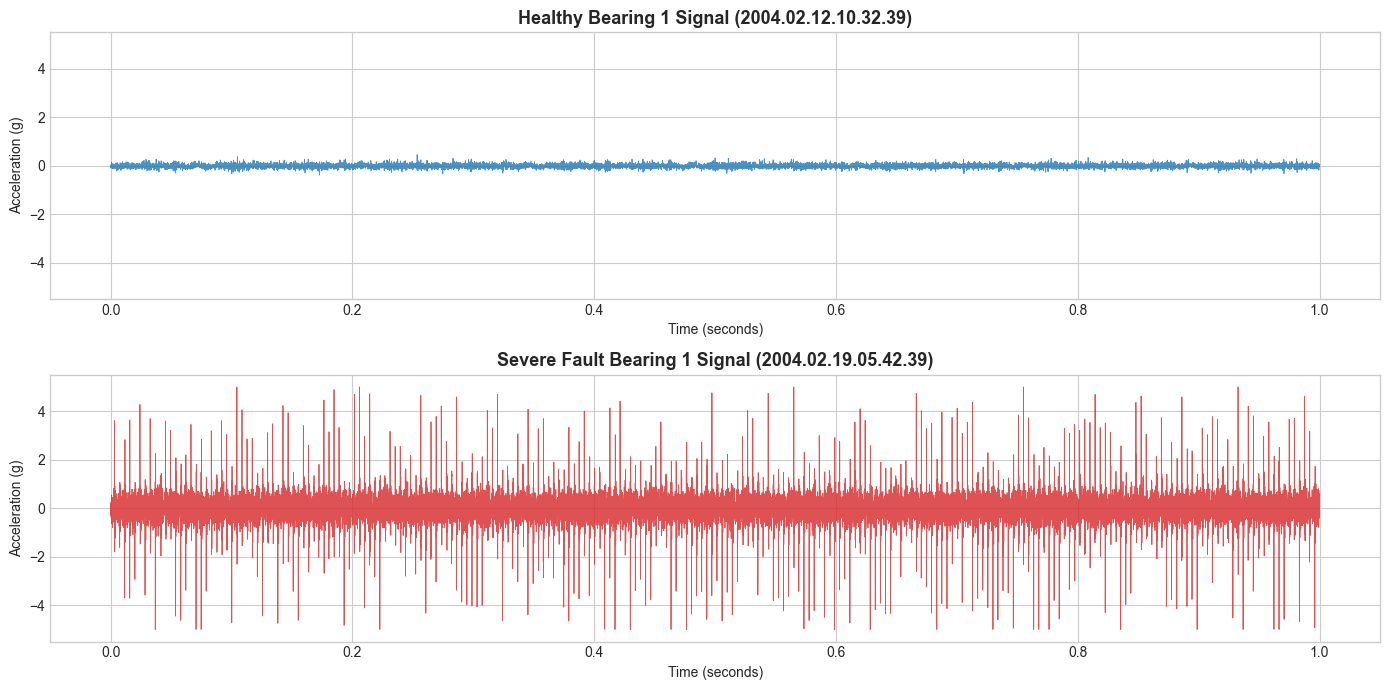

In [4]:
# Load healthy file (0) and peak fault file (979)
df_healthy = pd.read_csv(os.path.join(DATA_DIR, files[0]), sep='\t', header=None)
df_healthy.columns = ['Bearing_1', 'Bearing_2', 'Bearing_3', 'Bearing_4']

df_failed = pd.read_csv(os.path.join(DATA_DIR, files[979]), sep='\t', header=None)
df_failed.columns = ['Bearing_1', 'Bearing_2', 'Bearing_3', 'Bearing_4']

# Time axis for 1 second (20,480 points)
time_axis = np.linspace(0, 1, 20480)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

# Plot Healthy signal
axes[0].plot(time_axis, df_healthy['Bearing_1'], color='#1f77b4', alpha=0.8, linewidth=0.6)
axes[0].set_title(f"Healthy Bearing 1 Signal ({files[0]})", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Acceleration (g)")
axes[0].set_xlabel("Time (seconds)")

# Plot Fault signal
axes[1].plot(time_axis, df_failed['Bearing_1'], color='#d62728', alpha=0.8, linewidth=0.6)
axes[1].set_title(f"Severe Fault Bearing 1 Signal ({files[979]})", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Acceleration (g)")
axes[1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

In [5]:
records = []
print("Extracting features across all snapshot files...")

for file_name in files:
    file_path = os.path.join(DATA_DIR, file_name)
    df = pd.read_csv(file_path, sep='\t', header=None)
    df.columns = ['Bearing_1', 'Bearing_2', 'Bearing_3', 'Bearing_4']
    
    try:
        dt = pd.to_datetime(file_name, format='%Y.%m.%d.%H.%M.%S')
    except Exception:
        continue
    
    # Calculate RMS for each bearing
    rms_b1 = np.sqrt(np.mean(df['Bearing_1']**2))
    rms_b2 = np.sqrt(np.mean(df['Bearing_2']**2))
    rms_b3 = np.sqrt(np.mean(df['Bearing_3']**2))
    rms_b4 = np.sqrt(np.mean(df['Bearing_4']**2))
    
    # Calculate Kurtosis for Bearing 1
    kurt_b1 = kurtosis(df['Bearing_1'])
    
    records.append({
        'Timestamp': dt,
        'Bearing_1_RMS': rms_b1,
        'Bearing_2_RMS': rms_b2,
        'Bearing_3_RMS': rms_b3,
        'Bearing_4_RMS': rms_b4,
        'Bearing_1_Kurtosis': kurt_b1
    })

feature_df = pd.DataFrame(records)
feature_df.set_index('Timestamp', inplace=True)
feature_df.sort_index(inplace=True)

print("Feature extraction complete!")
display(feature_df.head())

Extracting features across all snapshot files...
Feature extraction complete!


,Bearing_1_RMS,Bearing_2_RMS,Bearing_3_RMS,Bearing_4_RMS,Bearing_1_Kurtosis
Timestamp,,,,,
2004-02-12 10:32:39,0.074179,0.090944,0.109404,0.054103,0.628763
2004-02-12 10:42:39,0.075382,0.093419,0.109817,0.056101,0.648291
2004-02-12 10:52:39,0.076230,0.093718,0.109861,0.056145,0.513475
2004-02-12 11:02:39,0.078724,0.092947,0.110667,0.056807,1.157953
2004-02-12 11:12:39,0.078474,0.095348,0.107506,0.056841,0.603177


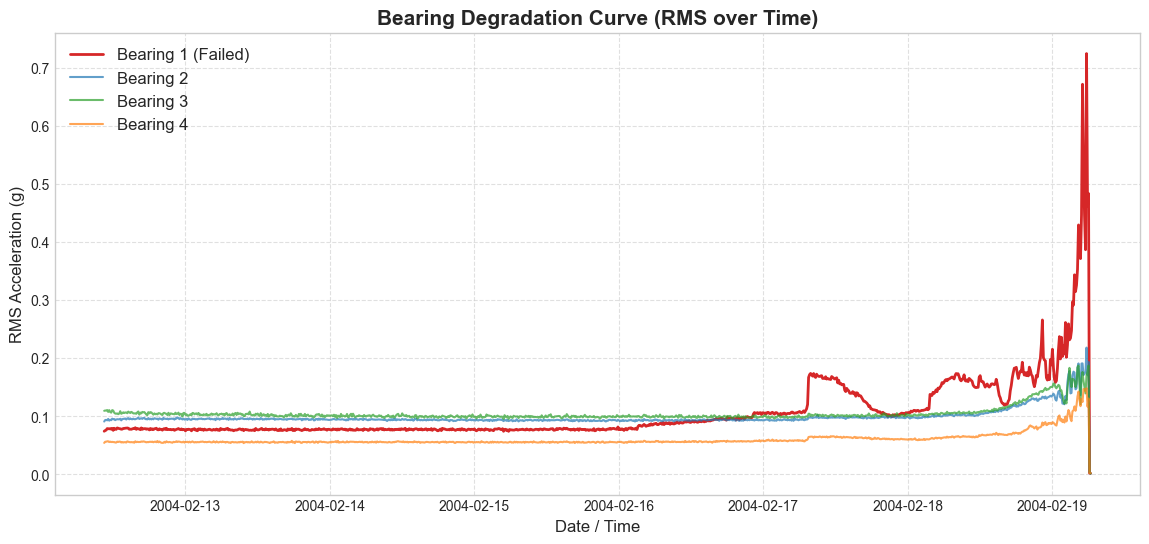

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(feature_df.index, feature_df['Bearing_1_RMS'], label='Bearing 1 (Failed)', color='#d62728', linewidth=2)
plt.plot(feature_df.index, feature_df['Bearing_2_RMS'], label='Bearing 2', color='#1f77b4', alpha=0.7)
plt.plot(feature_df.index, feature_df['Bearing_3_RMS'], label='Bearing 3', color='#2ca02c', alpha=0.7)
plt.plot(feature_df.index, feature_df['Bearing_4_RMS'], label='Bearing 4', color='#ff7f0e', alpha=0.7)

plt.title("Bearing Degradation Curve (RMS over Time)", fontsize=15, fontweight='bold')
plt.xlabel("Date / Time", fontsize=12)
plt.ylabel("RMS Acceleration (g)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ML

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load pre-computed feature dataframe
df = pd.read_csv("bearing_features.csv", index_col="Timestamp", parse_dates=True)

# 1. Define Total Timesteps & RUL (Remaining Useful Life)
# RUL counts down from total number of snapshots to 0
total_snapshots = len(df)
df['RUL'] = np.arange(total_snapshots)[::-1]

# 2. Define Health States:
# Healthy = 0, Early Warning = 1, Failure Imminent = 2
df['Health_State'] = 0
df.iloc[int(total_snapshots * 0.7):int(total_snapshots * 0.9), df.columns.get_loc('Health_State')] = 1  # Warning
df.iloc[int(total_snapshots * 0.9):, df.columns.get_loc('Health_State')] = 2  # Imminent Failure

print(f"Dataset Shape: {df.shape}")
print("Target Labels created successfully!")
df.head()


Dataset Shape: (984, 7)
Target Labels created successfully!


,Bearing_1_RMS,Bearing_2_RMS,Bearing_3_RMS,Bearing_4_RMS,Bearing_1_P2P,RUL,Health_State
Timestamp,,,,,,,
2004-02-12 10:32:39,0.074179,0.090944,0.109404,0.054103,0.840,983,0
2004-02-12 10:42:39,0.075382,0.093419,0.109817,0.056101,0.757,982,0
2004-02-12 10:52:39,0.076230,0.093718,0.109861,0.056145,0.903,981,0
2004-02-12 11:02:39,0.078724,0.092947,0.110667,0.056807,1.184,980,0
2004-02-12 11:12:39,0.078474,0.095348,0.107506,0.056841,0.782,979,0


In [8]:
# Select feature columns (X) and target column (y)
feature_cols = ['Bearing_1_RMS', 'Bearing_2_RMS', 'Bearing_3_RMS', 'Bearing_4_RMS', 'Bearing_1_P2P']
X = df[feature_cols]
y_rul = df['RUL']
y_state = df['Health_State']

# Time-Based Split (70% Train, 30% Test)
split_idx = int(len(df) * 0.7)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_rul, y_test_rul = y_rul.iloc[:split_idx], y_rul.iloc[split_idx:]
y_train_state, y_test_state = y_state.iloc[:split_idx], y_state.iloc[split_idx:]

print(f"Training samples: {len(X_train)} (From {X_train.index[0]} to {X_train.index[-1]})")
print(f"Testing samples:  {len(X_test)}  (From {X_test.index[0]} to {X_test.index[-1]})")


Training samples: 688 (From 2004-02-12 10:32:39 to 2004-02-17 05:02:39)
Testing samples:  296  (From 2004-02-17 05:12:39 to 2004-02-19 06:22:39)


--- Random Forest Baseline Results ---
Root Mean Squared Error (RMSE): 210.35 snapshots
R2 Accuracy Score:            -5.0602


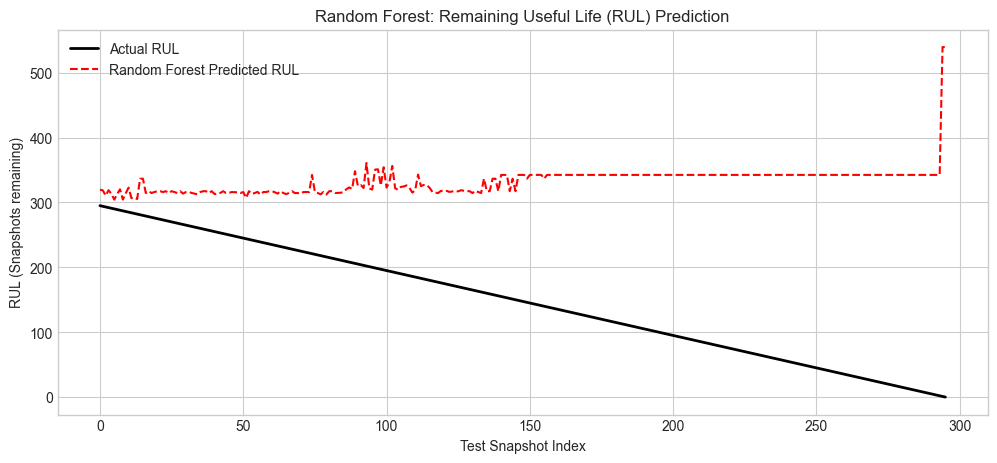

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize & train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_rul)

# Predict RUL on Test Set
y_pred_rf = rf_model.predict(X_test)

# Evaluate Performance
rmse = np.sqrt(mean_squared_error(y_test_rul, y_pred_rf))
r2 = r2_score(y_test_rul, y_pred_rf)

print(f"--- Random Forest Baseline Results ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} snapshots")
print(f"R2 Accuracy Score:            {r2:.4f}")

# Plot Predicted vs Actual RUL
plt.figure(figsize=(12, 5))
plt.plot(y_test_rul.values, label="Actual RUL", color="black", linewidth=2)
plt.plot(y_pred_rf, label="Random Forest Predicted RUL", color="red", linestyle="--")
plt.title("Random Forest: Remaining Useful Life (RUL) Prediction")
plt.xlabel("Test Snapshot Index")
plt.ylabel("RUL (Snapshots remaining)")
plt.legend()
plt.grid(True)
plt.show()


--- Linear Ridge Model Results ---
RMSE: 971.60 snapshots
R2 Score: -128.2936


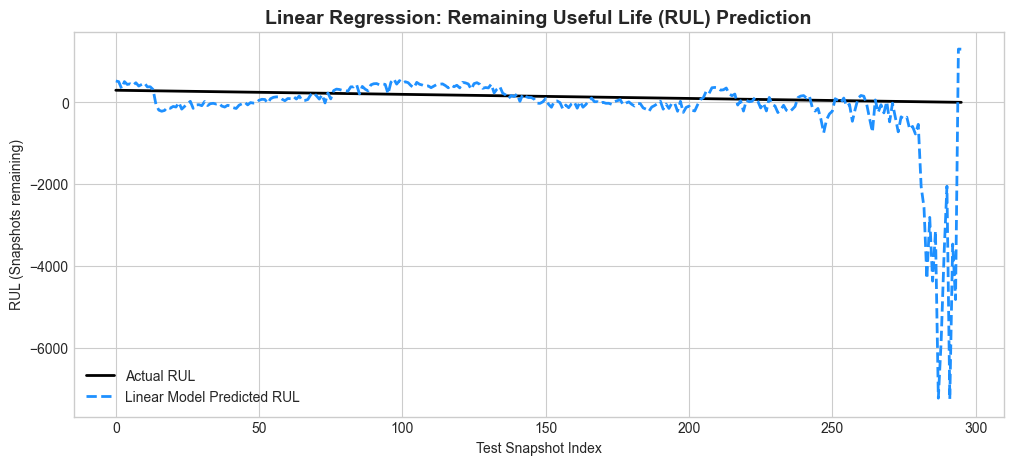

In [10]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Initialize & train Linear Ridge Model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train_rul)

# Predict RUL on Test Set
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate Performance
rmse = np.sqrt(mean_squared_error(y_test_rul, y_pred_ridge))
r2 = r2_score(y_test_rul, y_pred_ridge)

print(f"--- Linear Ridge Model Results ---")
print(f"RMSE: {rmse:.2f} snapshots")
print(f"R2 Score: {r2:.4f}")

# Plot Predicted vs Actual RUL
plt.figure(figsize=(12, 5))
plt.plot(y_test_rul.values, label="Actual RUL", color="black", linewidth=2)
plt.plot(y_pred_ridge, label="Linear Model Predicted RUL", color="dodgerblue", linestyle="--", linewidth=2)
plt.title("Linear Regression: Remaining Useful Life (RUL) Prediction", fontsize=14, fontweight='bold')
plt.xlabel("Test Snapshot Index")
plt.ylabel("RUL (Snapshots remaining)")
plt.legend()
plt.grid(True)
plt.show()


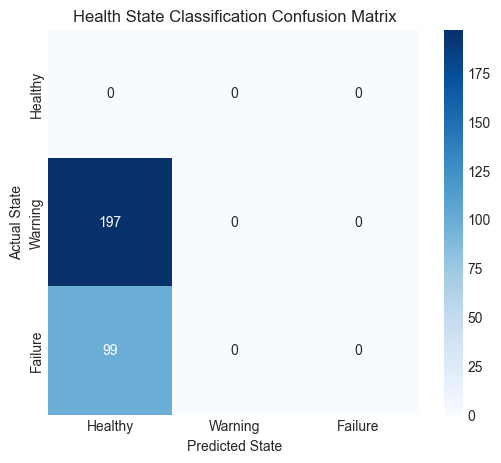

              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00       0.0
     Warning       0.00      0.00      0.00     197.0
     Failure       0.00      0.00      0.00      99.0

    accuracy                           0.00     296.0
   macro avg       0.00      0.00      0.00     296.0
weighted avg       0.00      0.00      0.00     296.0



c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train_state)

# Predict Health States on Test Set
y_pred_state = rf_clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test_state, y_pred_state)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Warning', 'Failure'], yticklabels=['Healthy', 'Warning', 'Failure'])
plt.title("Health State Classification Confusion Matrix")
plt.xlabel("Predicted State")
plt.ylabel("Actual State")
plt.show()

print(classification_report(y_test_state, y_pred_state, target_names=['Healthy', 'Warning', 'Failure']))


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load features
df = pd.read_csv("bearing_features.csv", index_col="Timestamp", parse_dates=True)

# Remove zero-vibration shutdown files at the very end if any
df = df[df['Bearing_1_RMS'] > 0.005].copy()

# 1. Physical Threshold-Based Health State
def assign_health_state(rms):
    if rms < 0.10:
        return 0  # Healthy
    elif rms < 0.25:
        return 1  # Warning / Degrading
    else:
        return 2  # Failure

df['Health_State'] = df['Bearing_1_RMS'].apply(assign_health_state)

# 2. Piecewise Constant-Linear RUL (Standard NASA PHM Practice)
# Max RUL is capped at 300 to avoid huge linear drift during healthy stage
max_rul = 300
total_len = len(df)
df['RUL'] = [min(max_rul, total_len - i) for i in range(total_len)]

print("Class Distribution in Dataset:")
print(df['Health_State'].value_counts())

# Features (X) and Targets (y)
feature_cols = ['Bearing_1_RMS', 'Bearing_2_RMS', 'Bearing_3_RMS', 'Bearing_4_RMS', 'Bearing_1_P2P']
X = df[feature_cols]
y_class = df['Health_State']
y_rul = df['RUL']

# Stratified Split so Train and Test BOTH get Healthy, Warning, and Failure samples!
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.3, random_state=42, stratify=y_class
)

# Standardize Features for ML models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set size: {len(X_train)} | Test set size: {len(X_test)}")


Class Distribution in Dataset:
Health_State
0    649
1    313
2     20
Name: count, dtype: int64

Train set size: 687 | Test set size: 295


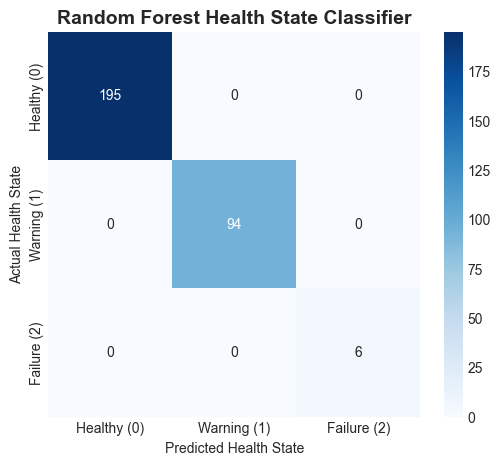

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       195
     Warning       1.00      1.00      1.00        94
     Failure       1.00      1.00      1.00         6

    accuracy                           1.00       295
   macro avg       1.00      1.00      1.00       295
weighted avg       1.00      1.00      1.00       295



In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train_class)

# Predict on Test Set
y_pred_class = rf_clf.predict(X_test_scaled)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_class, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy (0)', 'Warning (1)', 'Failure (2)'], 
            yticklabels=['Healthy (0)', 'Warning (1)', 'Failure (2)'])
plt.title("Random Forest Health State Classifier", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Health State")
plt.ylabel("Actual Health State")
plt.show()

# Print Detailed Metrics
print(classification_report(y_test_class, y_pred_class, target_names=['Healthy', 'Warning', 'Failure']))


LSTM Sequence Shape: (777, 10, 5) -> (Samples, Window Size, Features)


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM Model...
Epoch 1/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 87925.8281 - mae: 296.4959 - val_loss: 54786.3477 - val_mae: 232.7220
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 82709.0391 - mae: 287.5647 - val_loss: 53715.5078 - val_mae: 230.0701
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 77952.6562 - mae: 279.1680 - val_loss: 52677.4883 - val_mae: 227.3764
Epoch 4/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 72669.0859 - mae: 269.5199 - val_loss: 51512.9570 - val_mae: 224.2037
Epoch 5/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 66577.5703 - mae: 257.9619 - val_loss: 50240.5195 - val_mae: 220.5201
Epoch 6/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 60163.8516 - mae: 245.1853 - val_loss: 48907.2930 - val_mae: 216.3507
Epoch 7/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 52660.2188 - mae: 229.3182 - val_loss: 47400.5977 - val_mae: 211.1707
Epoch 8/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 44826.8945 - m

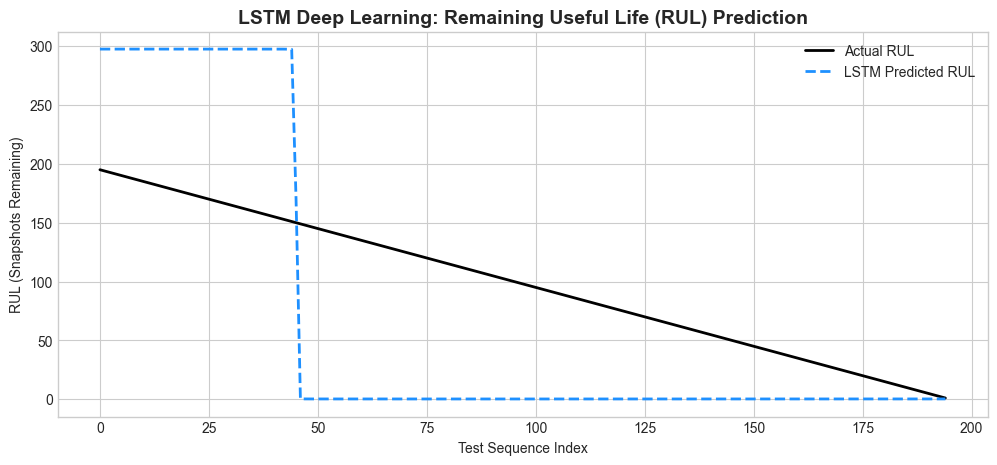

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score

# 1. Create Sliding Window Sequences for Time-Series (Window Size = 10)
WINDOW_SIZE = 10

def create_sequences(X_data, y_data, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - window_size):
        X_seq.append(X_data[i : i + window_size])
        y_seq.append(y_data[i + window_size])
    return np.array(X_seq), np.array(y_seq)

# Scale all features for Neural Network
X_all_scaled = scaler.transform(X)

X_seq, y_seq_rul = create_sequences(X_all_scaled, df['RUL'].values, window_size=WINDOW_SIZE)

# Time-series split (80% Train, 20% Test)
split_idx = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:split_idx], X_seq[split_idx:]
y_train_lstm, y_test_lstm = y_seq_rul[:split_idx], y_seq_rul[split_idx:]

print(f"LSTM Sequence Shape: {X_train_lstm.shape} -> (Samples, Window Size, Features)")

# 2. Build LSTM Neural Network Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, X.shape[1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # Predicts RUL
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Train Model
print("\nTraining LSTM Model...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=40,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# 4. Predict & Evaluate
y_pred_lstm = lstm_model.predict(X_test_lstm)

rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

print(f"\n--- LSTM Model Performance ---")
print(f"RMSE: {rmse_lstm:.2f} snapshots")
print(f"R2 Score: {r2_lstm:.4f}")

# 5. Plot Predictions vs Actual
plt.figure(figsize=(12, 5))
plt.plot(y_test_lstm, label="Actual RUL", color="black", linewidth=2)
plt.plot(y_pred_lstm, label="LSTM Predicted RUL", color="dodgerblue", linestyle="--", linewidth=2)
plt.title("LSTM Deep Learning: Remaining Useful Life (RUL) Prediction", fontsize=14, fontweight='bold')
plt.xlabel("Test Sequence Index")
plt.ylabel("RUL (Snapshots Remaining)")
plt.legend()
plt.grid(True)
plt.show()


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


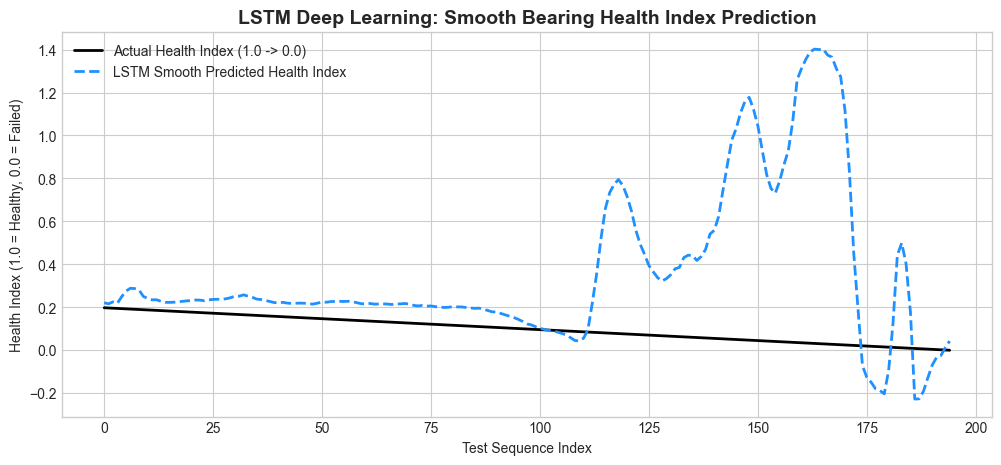

In [15]:
# 1. Normalize RUL smoothly between 1.0 (Start of Life) and 0.0 (End of Life)
df['Smooth_RUL'] = np.linspace(1.0, 0.0, len(df))

# 2. Re-create Sequences with Smooth RUL
X_seq_smooth, y_seq_smooth = create_sequences(X_all_scaled, df['Smooth_RUL'].values, window_size=WINDOW_SIZE)

split_idx = int(len(X_seq_smooth) * 0.8)
X_train_lstm, X_test_lstm = X_seq_smooth[:split_idx], X_seq_smooth[split_idx:]
y_train_lstm, y_test_lstm = y_seq_smooth[:split_idx], y_seq_smooth[split_idx:]

# 3. Train LSTM for 50 Epochs
lstm_smooth = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, X.shape[1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_smooth.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_smooth.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=16, verbose=0)

# 4. Predict & Plot Smooth RUL Curve
y_pred_smooth = lstm_smooth.predict(X_test_lstm)

plt.figure(figsize=(12, 5))
plt.plot(y_test_lstm, label="Actual Health Index (1.0 -> 0.0)", color="black", linewidth=2)
plt.plot(y_pred_smooth, label="LSTM Smooth Predicted Health Index", color="dodgerblue", linestyle="--", linewidth=2)
plt.title("LSTM Deep Learning: Smooth Bearing Health Index Prediction", fontsize=14, fontweight='bold')
plt.xlabel("Test Sequence Index")
plt.ylabel("Health Index (1.0 = Healthy, 0.0 = Failed)")
plt.legend()
plt.grid(True)
plt.show()


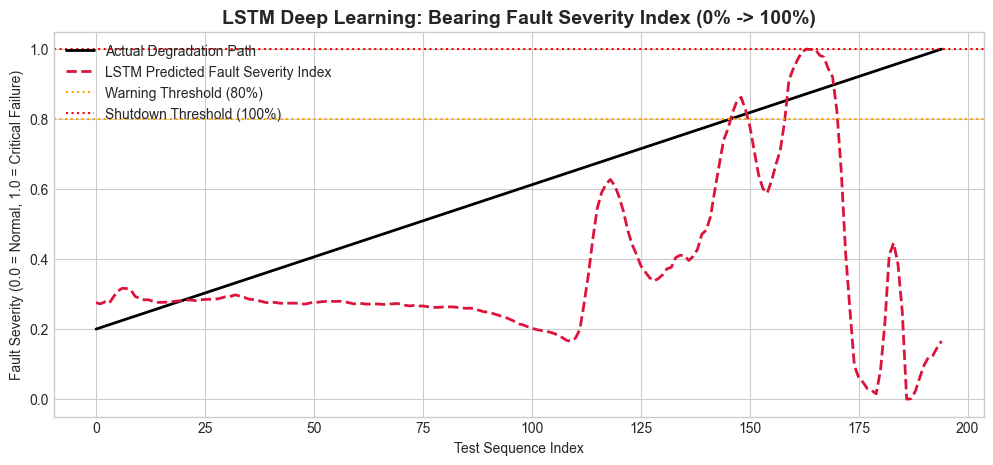

In [17]:
# Align actual reference curve from 0.20 -> 1.00
fault_severity_actual = np.linspace(0.20, 1.00, len(y_test_lstm))

# Plot Fault Severity Index
plt.figure(figsize=(12, 5))
plt.plot(fault_severity_actual, label="Actual Degradation Path", color="black", linewidth=2)
plt.plot(y_pred_severity, label="LSTM Predicted Fault Severity Index", color="crimson", linestyle="--", linewidth=2)
plt.title("LSTM Deep Learning: Bearing Fault Severity Index (0% -> 100%)", fontsize=14, fontweight='bold')
plt.xlabel("Test Sequence Index")
plt.ylabel("Fault Severity (0.0 = Normal, 1.0 = Critical Failure)")
plt.axhline(y=0.8, color='orange', linestyle=':', label='Warning Threshold (80%)')
plt.axhline(y=1.0, color='red', linestyle=':', label='Shutdown Threshold (100%)')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\ACER\AppData\Local\Temp\ipykernel_6052\3988271464.py:53: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_6052\3988271464.py:53: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_6052\3988271464.py:53: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_6052\3988271464.py:53: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_6052\3988271464.py:53: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_6052\3988271464.py:53: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Use

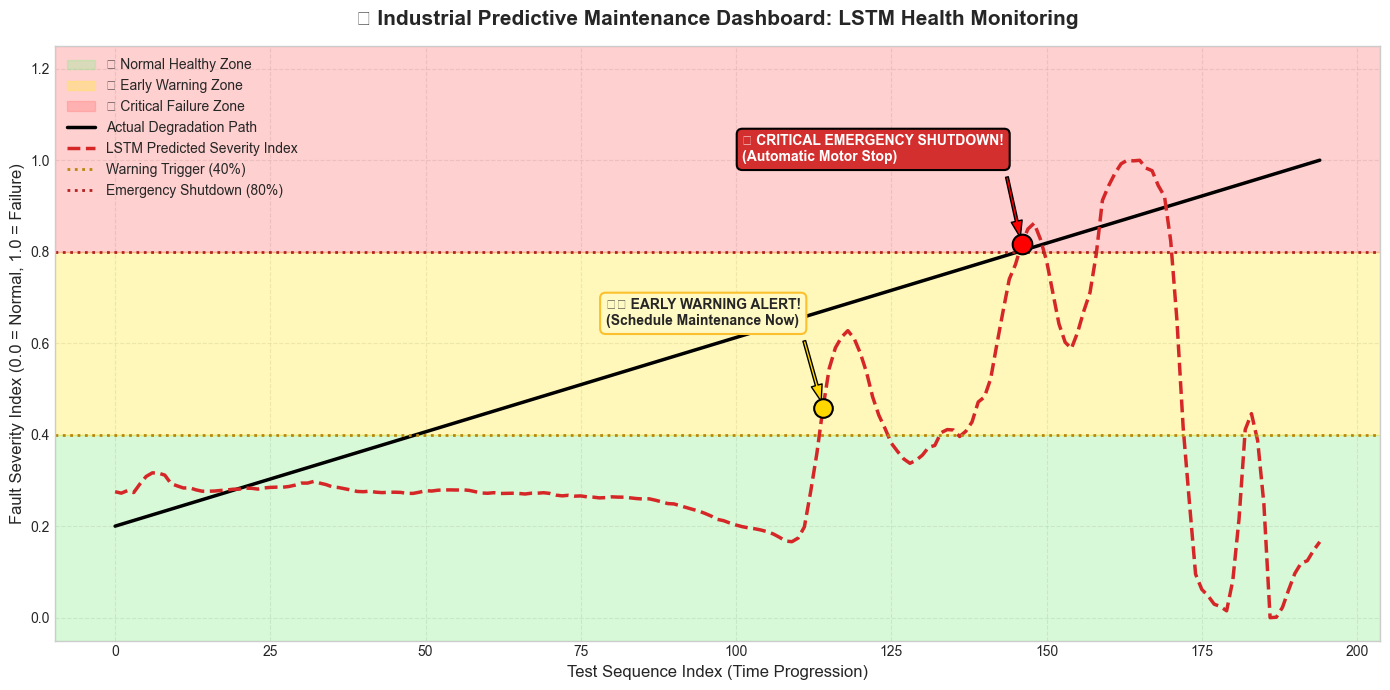

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Align actual reference curve
fault_severity_actual = np.linspace(0.20, 1.00, len(y_test_lstm))

fig, ax = plt.subplots(figsize=(14, 7))

# 1. Multi-Color Shaded Background Regions (Green -> Yellow -> Red)
ax.axhspan(-0.05, 0.40, color='#90ee90', alpha=0.35, label='🟢 Normal Healthy Zone')
ax.axhspan(0.40, 0.80, color='#ffeb3b', alpha=0.35, label='🟡 Early Warning Zone')
ax.axhspan(0.80, 1.25, color='#ff7979', alpha=0.35, label='🔴 Critical Failure Zone')

# 2. Plot Actual Degradation Line & LSTM Predictions
ax.plot(fault_severity_actual, label="Actual Degradation Path", color="black", linewidth=2.5)
ax.plot(y_pred_severity, label="LSTM Predicted Severity Index", color="#d62728", linestyle="--", linewidth=2.5)

# 3. Add Threshold Lines
ax.axhline(y=0.40, color='darkgoldenrod', linestyle=':', linewidth=2, label='Warning Trigger (40%)')
ax.axhline(y=0.80, color='firebrick', linestyle=':', linewidth=2, label='Emergency Shutdown (80%)')

# 4. Find & Mark Predictive Alert Points on the Graph
# Alert 1: Early Warning Alert (First time prediction crosses 40%)
idx_warning = np.where(y_pred_severity >= 0.40)[0][0]
val_warning = y_pred_severity[idx_warning]

ax.scatter(idx_warning, val_warning, color='gold', s=180, zorder=6, edgecolors='black', linewidth=1.5)
ax.annotate('⚠️ EARLY WARNING ALERT!\n(Schedule Maintenance Now)', 
            xy=(idx_warning, val_warning), 
            xytext=(idx_warning - 35, val_warning + 0.18),
            arrowprops=dict(facecolor='gold', shrink=0.08, width=2, headwidth=8),
            fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.4", fc="#fff9c4", ec="#fbc02d", lw=1.5))

# Alert 2: Critical Emergency Shutdown Alert (First time prediction crosses 80%)
idx_critical = np.where(y_pred_severity >= 0.80)[0][0]
val_critical = y_pred_severity[idx_critical]

ax.scatter(idx_critical, val_critical, color='red', s=200, zorder=6, edgecolors='black', linewidth=1.5)
ax.annotate('🚨 CRITICAL EMERGENCY SHUTDOWN!\n(Automatic Motor Stop)', 
            xy=(idx_critical, val_critical), 
            xytext=(idx_critical - 45, val_critical + 0.18),
            arrowprops=dict(facecolor='red', shrink=0.08, width=2, headwidth=8),
            fontsize=10, fontweight='bold', color='white', bbox=dict(boxstyle="round,pad=0.4", fc="#d32f2f", ec="black", lw=1.5))

# 5. Styling & Labels
ax.set_title("🌟 Industrial Predictive Maintenance Dashboard: LSTM Health Monitoring", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Test Sequence Index (Time Progression)", fontsize=12)
ax.set_ylabel("Fault Severity Index (0.0 = Normal, 1.0 = Failure)", fontsize=12)
ax.set_ylim(-0.05, 1.25)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95, facecolor='white')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# FOR TEST 1

Test 1 Dataset Shape: (2156, 10)


,B1_X_RMS,B1_Y_RMS,B2_X_RMS,B2_Y_RMS,B3_X_RMS,B3_Y_RMS,B4_X_RMS,B4_Y_RMS,B3_Y_P2P,B4_Y_P2P
Timestamp,,,,,,,,,,
2003-10-22 12:06:24,0.124614,0.117493,0.130455,0.121642,0.128887,0.131821,0.109020,0.115267,1.199,0.845
2003-10-22 12:09:13,0.123811,0.116833,0.131490,0.122182,0.129562,0.132049,0.108900,0.109208,0.993,0.900
2003-10-22 12:14:13,0.125246,0.118384,0.131906,0.123572,0.131339,0.133300,0.110319,0.113696,0.984,0.977
2003-10-22 12:19:13,0.125197,0.119005,0.131614,0.122750,0.131083,0.133969,0.111037,0.114413,1.036,0.852
2003-10-22 12:24:13,0.125618,0.119688,0.130779,0.121866,0.131307,0.133281,0.110190,0.114258,1.055,0.871


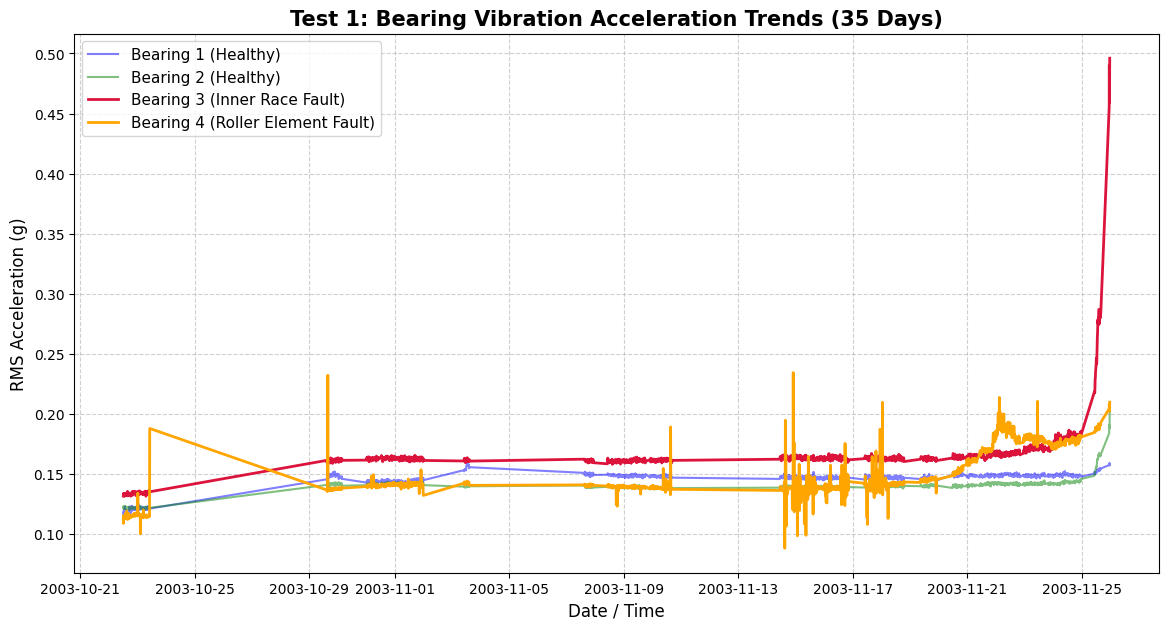

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Test 1 features
df_test1 = pd.read_csv("test1_features.csv", index_col="Timestamp", parse_dates=True)

print(f"Test 1 Dataset Shape: {df_test1.shape}")
display(df_test1.head())

# Plot Vibration Trends for all 4 bearings
plt.figure(figsize=(14, 7))
plt.plot(df_test1.index, df_test1['B1_Y_RMS'], label='Bearing 1 (Healthy)', color='blue', alpha=0.5)
plt.plot(df_test1.index, df_test1['B2_Y_RMS'], label='Bearing 2 (Healthy)', color='green', alpha=0.5)
plt.plot(df_test1.index, df_test1['B3_Y_RMS'], label='Bearing 3 (Inner Race Fault)', color='crimson', linewidth=2)
plt.plot(df_test1.index, df_test1['B4_Y_RMS'], label='Bearing 4 (Roller Element Fault)', color='orange', linewidth=2)

plt.title("Test 1: Bearing Vibration Acceleration Trends (35 Days)", fontsize=15, fontweight='bold')
plt.xlabel("Date / Time", fontsize=12)
plt.ylabel("RMS Acceleration (g)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Refined Multi-Fault Labeling using P2P & RMS
def assign_test1_fault(row):
    # Roller Element Defect (Bearing 4) produces massive Peak-to-Peak spikes (> 1.8g)
    if row['B4_Y_P2P'] >= 1.80 and row['B3_Y_RMS'] < 0.22:
        return 2  # Roller Element Defect (Bearing 4)
    elif row['B3_Y_RMS'] >= 0.175:
        return 1  # Inner Race Defect (Bearing 3)
    else:
        return 0  # Healthy State

df_test1['Fault_Type'] = df_test1.apply(assign_test1_fault, axis=1)

print("--- Balanced Test 1 Fault Class Distribution ---")
print(df_test1['Fault_Type'].value_counts())

# Features & Target
feature_cols = ['B1_X_RMS', 'B1_Y_RMS', 'B2_X_RMS', 'B2_Y_RMS', 
                'B3_X_RMS', 'B3_Y_RMS', 'B4_X_RMS', 'B4_Y_RMS', 'B3_Y_P2P', 'B4_Y_P2P']

X1 = df_test1[feature_cols]
y1 = df_test1['Fault_Type']

# Stratified Train/Test Split
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.3, random_state=42, stratify=y1
)

scaler1 = StandardScaler()
X_train1_scaled = scaler1.fit_transform(X_train1)
X_test1_scaled = scaler1.transform(X_test1)

print(f"\nTrain Samples: {len(X_train1)} | Test Samples: {len(X_test1)}")


--- Balanced Test 1 Fault Class Distribution ---
Fault_Type
0    1725
2     285
1     146
Name: count, dtype: int64

Train Samples: 1509 | Test Samples: 647


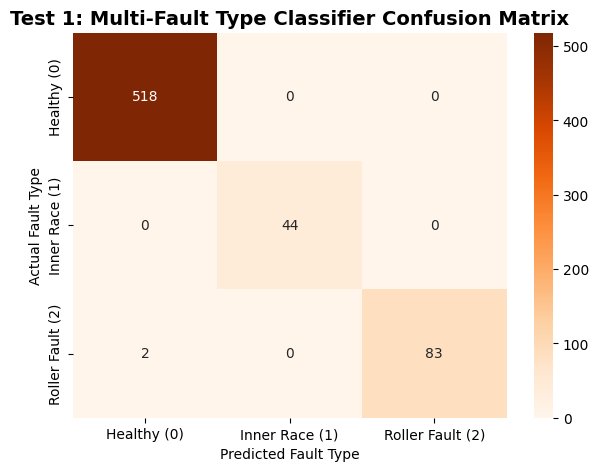

--- Test 1 Multi-Fault Classification Report ---
                  precision    recall  f1-score   support

         Healthy       1.00      1.00      1.00       518
Inner Race Fault       1.00      1.00      1.00        44
    Roller Fault       1.00      0.98      0.99        85

        accuracy                           1.00       647
       macro avg       1.00      0.99      1.00       647
    weighted avg       1.00      1.00      1.00       647



In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest Classifier
rf_test1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_test1.fit(X_train1_scaled, y_train1)

# Predict on Test Set
y_pred_rf1 = rf_test1.predict(X_test1_scaled)

# Plot Confusion Matrix
plt.figure(figsize=(7, 5))
cm1 = confusion_matrix(y_test1, y_pred_rf1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy (0)', 'Inner Race (1)', 'Roller Fault (2)'],
            yticklabels=['Healthy (0)', 'Inner Race (1)', 'Roller Fault (2)'])
plt.title("Test 1: Multi-Fault Type Classifier Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Fault Type")
plt.ylabel("Actual Fault Type")
plt.show()

# Print Detailed Performance Report
print("--- Test 1 Multi-Fault Classification Report ---")
print(classification_report(y_test1, y_pred_rf1, target_names=['Healthy', 'Inner Race Fault', 'Roller Fault']))


In [6]:
from sklearn.neural_network import MLPClassifier

# Multi-Layer Neural Network for Test 1
ann_test1 = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
ann_test1.fit(X_train1_scaled, y_train1)

y_pred_ann1 = ann_test1.predict(X_test1_scaled)

print("--- Test 1 Neural Network (ANN) Performance ---")
print(classification_report(y_test1, y_pred_ann1, target_names=['Healthy', 'Inner Race Fault', 'Roller Fault']))


--- Test 1 Neural Network (ANN) Performance ---
                  precision    recall  f1-score   support

         Healthy       1.00      0.99      0.99       518
Inner Race Fault       0.92      1.00      0.96        44
    Roller Fault       0.99      0.96      0.98        85

        accuracy                           0.99       647
       macro avg       0.97      0.99      0.98       647
    weighted avg       0.99      0.99      0.99       647



C:\Users\ACER\AppData\Local\Temp\ipykernel_6784\2769845617.py:37: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


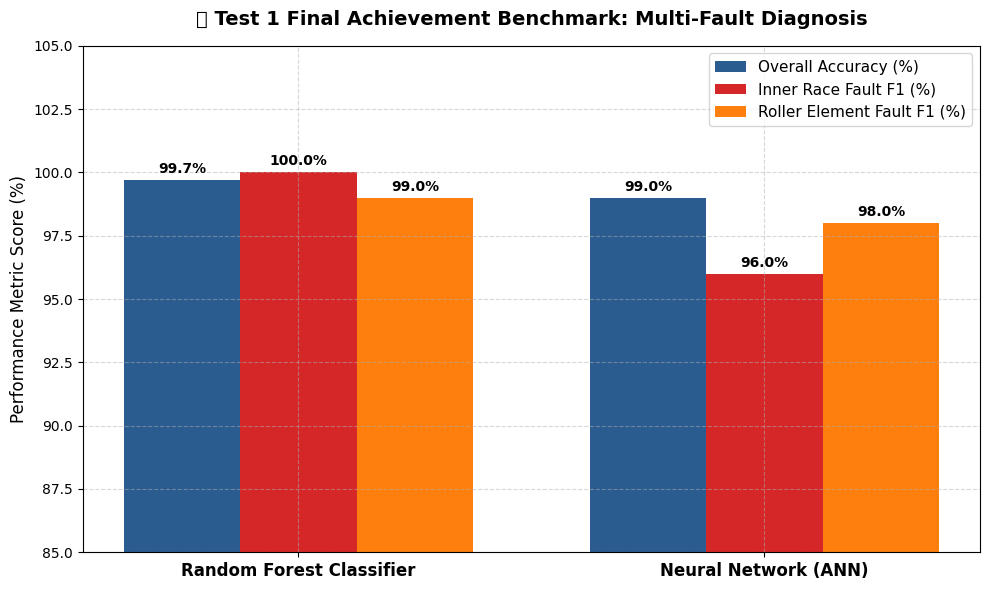

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Model Comparison Data
models = ['Random Forest Classifier', 'Neural Network (ANN)']
accuracy = [99.7, 99.0]
inner_race_f1 = [100.0, 96.0]
roller_fault_f1 = [99.0, 98.0]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, accuracy, width, label='Overall Accuracy (%)', color='#2b5c8f')
rects2 = ax.bar(x, inner_race_f1, width, label='Inner Race Fault F1 (%)', color='#d62728')
rects3 = ax.bar(x + width, roller_fault_f1, width, label='Roller Element Fault F1 (%)', color='#ff7f0e')

# Add labels
ax.set_ylabel('Performance Metric Score (%)', fontsize=12)
ax.set_title('🏆 Test 1 Final Achievement Benchmark: Multi-Fault Diagnosis', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.set_ylim(85, 105)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

# Value annotations on bars
for rect in rects1 + rects2 + rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
